# 8. Word2Vec sobre 6-gramas del hipnograma

Este notebook entrena un modelo **Word2Vec Skip-Gram** sobre el corpus unificado de 127 pacientes sanos (CAP + Sleep-EDF + SCO) usando como tokens **6-gramas** de fases del sueño. La elección de N=6 está justificada empíricamente en el notebook 7 (criterio combinado |β−1|, R², cobertura de bloques S2).

## Plan de trabajo

1. Cargar el corpus unificado y separarlo por paciente.
2. Tokenizar cada hipnograma en 6-gramas (**a-b-c-d-e-f**) y, en paralelo, en unigramas para contraste.
3. Construir vocabularios filtrando hápax (**min_frecuencia=2**).
4. Entrenar dos Skip-Gram independientes con softmax completo (vocab manejable).
5. Extraer embeddings, normalizar y analizar similitud coseno + vecinos cercanos.
6. Proyectar a 2D y 3D con UMAP (métrica coseno).
7. Comparar la distribución de tokens y embeddings promedio entre CAP / EDF / SCO.

## Diferencias respecto al prototipo inicial

Una primera versión exploratoria usó solo 10 pacientes (SCO); este notebook escala a la cohorte unificada de 127. Lo esencial del método no cambia:

| Aspecto | Prototipo (10 SCO) | Este notebook (127) |
|---|---|---|
| Pacientes | 10 (SCO) | 127 (CAP + EDF + SCO) |
| Fuente | un archivo Scoring por paciente | dataset/epocas_unificado.csv |
| Token 6g | cadena 'a-b-c-d-e-f' | igual |
| min_frecuencia | 2 | 2 (igual) |
| Vocabulario 6g | 424 | ~1500 (corpus ~12× mayor) |
| Dim embedding 6g / 1g | 32 / 24 | igual |
| Ventana skip-gram 6g / 1g | 1 / 3 | igual |
| Optimizador / softmax | Adam / completo | igual |
| Análisis entre cohortes | — | añadido (sección 13) |
| K-Means + silhouette | sí | omitido (ver conclusiones) |

## 1. Imports y configuración

In [1]:
import os
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
from umap import UMAP

RUTA_BASE = Path('..').resolve()
RUTA_DATOS = RUTA_BASE / 'dataset' / 'epocas_unificado.csv'
RUTA_MODELOS = RUTA_BASE / 'modelos'
RUTA_IMG = RUTA_BASE / 'imagenes' / 'word2vec'
RUTA_STATS = RUTA_BASE / 'estadisticas'
RUTA_MODELOS.mkdir(parents=True, exist_ok=True)
RUTA_IMG.mkdir(parents=True, exist_ok=True)
RUTA_STATS.mkdir(parents=True, exist_ok=True)

ETIQUETAS_FASE = {
    0: 'Vigilia (W)',
    1: 'S1',
    2: 'S2',
    3: 'SWS',
    4: 'REM',
    5: 'Sin clasificar',
}

COLORES_FASE = {
    0: '#E6E6FA',
    1: '#ADD8E6',
    2: '#ADFF2F',
    3: '#FF7F50',
    4: '#4169E1',
    5: '#A9A9A9',
}

SEMILLA = 42
torch.manual_seed(SEMILLA)
np.random.seed(SEMILLA)
DISPOSITIVO = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DISPOSITIVO}')

Dispositivo: cpu


## 2. Carga del corpus unificado

In [2]:
df = pd.read_csv(RUTA_DATOS)
df = df.sort_values(['paciente', 'epoca']).reset_index(drop=True)
print(f'Total épocas: {len(df):,}')
print(f'Pacientes: {df["paciente"].nunique()}')
print(df.groupby('dataset')['paciente'].nunique().rename('n_pacientes'))

secuencias_por_paciente = {
    pid: g['fase_num'].tolist()
    for pid, g in df.groupby('paciente', sort=False)
}
dataset_por_paciente = df.drop_duplicates('paciente').set_index('paciente')['dataset'].to_dict()
longitudes = pd.Series({pid: len(s) for pid, s in secuencias_por_paciente.items()})
print(f'\nLongitud por paciente: media={longitudes.mean():.0f}, min={longitudes.min()}, max={longitudes.max()}')

Total épocas: 112,809
Pacientes: 127
dataset
CAP    16
EDF    82
SCO    29
Name: n_pacientes, dtype: int64

Longitud por paciente: media=888, min=442, max=1639


## 3. Tokenización (6-gramas y unigramas)

- **Token principal (6-grama)**: cada ventana deslizante de 6 fases se codifica como **'a-b-c-d-e-f'**.
- **Token auxiliar (unigrama)**: cada fase individual como **'a'**. Permite contrastar embeddings de fase atómica vs. patrón temporal.

In [3]:
N = 6

def tokenizar_ngramas(secuencia, n):
    if len(secuencia) < n:
        return []
    return ['-'.join(str(v) for v in secuencia[i:i+n]) for i in range(len(secuencia) - n + 1)]

corpus_6g, corpus_1g, meta_documentos = [], [], []
for pid, secuencia in secuencias_por_paciente.items():
    documento_6g = tokenizar_ngramas(secuencia, N)
    documento_1g = [str(v) for v in secuencia]
    if not documento_6g:
        continue
    corpus_6g.append(documento_6g)
    corpus_1g.append(documento_1g)
    meta_documentos.append({'paciente': pid, 'dataset': dataset_por_paciente[pid]})

meta_documentos = pd.DataFrame(meta_documentos)
print(f'Documentos válidos: {len(corpus_6g)}')
print(f'Tokens 6g (con repetición): {sum(len(d) for d in corpus_6g):,}')
print(f'Tokens 1g (con repetición): {sum(len(d) for d in corpus_1g):,}')

Documentos válidos: 127
Tokens 6g (con repetición): 112,174
Tokens 1g (con repetición): 112,809


## 4. Vocabulario

Filtramos tokens con **min_frecuencia=2** (descarta hápax). En el corpus unificado los hápax son ~47 % del vocabulario pero solo ~1 % del corpus, por lo que el filtro elimina ruido sin perder cobertura.

In [4]:
MIN_FREQ = 2

def construir_vocabulario(corpus, min_freq):
    contador = Counter()
    for documento in corpus:
        contador.update(documento)
    vocab = {t for t, f in contador.items() if f >= min_freq}
    idx_por_token = {t: i for i, t in enumerate(sorted(vocab))}
    token_por_idx = {i: t for t, i in idx_por_token.items()}
    frecuencias = {t: contador[t] for t in vocab}
    total = sum(contador.values())
    cubiertos = sum(frecuencias.values())
    cobertura = cubiertos / total if total else 0.0
    return idx_por_token, token_por_idx, frecuencias, cobertura

idx_6g, tok_6g, frec_6g, cob_6g = construir_vocabulario(corpus_6g, MIN_FREQ)
idx_1g, tok_1g, frec_1g, cob_1g = construir_vocabulario(corpus_1g, MIN_FREQ)

print(f'Vocab 6g: {len(idx_6g):,} tokens (cobertura {cob_6g*100:.2f}%)')
print(f'Vocab 1g: {len(idx_1g)} tokens (cobertura {cob_1g*100:.2f}%)')

df_vocab_6g = pd.DataFrame(sorted(frec_6g.items(), key=lambda x: -x[1]), columns=['token', 'frecuencia'])
df_vocab_6g.head(15)

Vocab 6g: 1,503 tokens (cobertura 98.83%)
Vocab 1g: 6 tokens (cobertura 100.00%)


,token,frecuencia
0,2-2-2-2-2-2,37436
1,4-4-4-4-4-4,17620
2,3-3-3-3-3-3,12161
3,0-0-0-0-0-0,4704
4,1-1-1-1-1-1,1501
5,1-2-2-2-2-2,1236
6,2-2-2-2-2-3,930
7,1-1-2-2-2-2,803
8,2-2-2-2-3-2,586
9,2-3-3-3-3-3,568


In [5]:
df_vocab_6g.to_csv(RUTA_STATS / 'word2vec_vocab_6g.csv', index=False)
pd.DataFrame(sorted(frec_1g.items(), key=lambda x: -x[1]), columns=['token', 'frecuencia']).to_csv(
    RUTA_STATS / 'word2vec_vocab_1g.csv', index=False
)
print('Vocabularios guardados en estadisticas/.')

Vocabularios guardados en estadisticas/.


## 5. Dataset Skip-Gram

Para cada token construimos pares **(target, contexto)** con ventana simétrica.
- 6-gramas: ventana = 1 (vecinos inmediatos).
- Unigramas: ventana = 3 (captura contexto más amplio dado el vocab pequeño).

In [6]:
class DatasetSkipGram(Dataset):
    def __init__(self, corpus, idx_por_token, ventana):
        pares = []
        for documento in corpus:
            indices = [idx_por_token[t] for t in documento if t in idx_por_token]
            for pos, target in enumerate(indices):
                inicio = max(0, pos - ventana)
                fin = min(len(indices), pos + ventana + 1)
                for pc in range(inicio, fin):
                    if pc != pos:
                        pares.append((target, indices[pc]))
        self.pares = torch.tensor(pares, dtype=torch.long)

    def __len__(self):
        return self.pares.shape[0]

    def __getitem__(self, idx):
        return self.pares[idx, 0], self.pares[idx, 1]

VENTANA_6G = 1
VENTANA_1G = 3
BATCH = 512

ds_6g = DatasetSkipGram(corpus_6g, idx_6g, VENTANA_6G)
ds_1g = DatasetSkipGram(corpus_1g, idx_1g, VENTANA_1G)
print(f'Pares 6g: {len(ds_6g):,}')
print(f'Pares 1g: {len(ds_1g):,}')

loader_6g = DataLoader(ds_6g, batch_size=BATCH, shuffle=True)
loader_1g = DataLoader(ds_1g, batch_size=BATCH, shuffle=True)

Pares 6g: 221,466
Pares 1g: 675,330


## 6. Modelo Word2Vec (Skip-Gram softmax completo)

Vocab manejable (≤2 000 tokens) ⇒ usamos softmax completo sin negative sampling. Implementación idéntica a la del prototipo inicial.

In [7]:
class ModeloWord2Vec(nn.Module):
    def __init__(self, tam_vocab, dim_embedding):
        super().__init__()
        self.embeddings = nn.Embedding(tam_vocab, dim_embedding)
        self.salida = nn.Linear(dim_embedding, tam_vocab)

    def forward(self, x):
        return self.salida(self.embeddings(x))

def entrenar(loader, tam_vocab, dim, epocas, lr, dispositivo):
    modelo = ModeloWord2Vec(tam_vocab, dim).to(dispositivo)
    criterio = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    historial = []
    for ep in range(1, epocas + 1):
        modelo.train()
        acumulada = 0.0
        n_batches = 0
        for target, contexto in loader:
            target = target.to(dispositivo)
            contexto = contexto.to(dispositivo)
            opt.zero_grad()
            logits = modelo(target)
            loss = criterio(logits, contexto)
            loss.backward()
            opt.step()
            acumulada += loss.item()
            n_batches += 1
        media = acumulada / max(n_batches, 1)
        historial.append(media)
        if ep == 1 or ep % 5 == 0 or ep == epocas:
            print(f'  época {ep:3d}/{epocas}  pérdida media={media:.4f}')
    return modelo, historial

## 7. Entrenamiento

- 6-gramas: dim=32, 30 épocas, lr=0.01.
- Unigramas: dim=24, 20 épocas, lr=0.01.

In [8]:
print('=== Entrenando Word2Vec 6-gramas ===')
modelo_6g, hist_6g = entrenar(loader_6g, len(idx_6g), 32, epocas=30, lr=0.01, dispositivo=DISPOSITIVO)
torch.save({
    'state_dict': modelo_6g.state_dict(),
    'idx_por_token': idx_6g,
    'dim': 32,
    'min_freq': MIN_FREQ,
}, RUTA_MODELOS / 'word2vec_6g.pt')
print('Modelo 6g guardado.')

=== Entrenando Word2Vec 6-gramas ===


  época   1/30  pérdida media=1.3053


  época   5/30  pérdida media=0.7481


  época  10/30  pérdida media=0.7265


  época  15/30  pérdida media=0.7195


  época  20/30  pérdida media=0.7157


  época  25/30  pérdida media=0.7131


  época  30/30  pérdida media=0.7109
Modelo 6g guardado.


In [9]:
ruta_1g = RUTA_MODELOS / 'word2vec_1g.pt'
if ruta_1g.exists():
    print('=== Cargando Word2Vec unigramas desde caché ===')
    checkpoint = torch.load(ruta_1g, map_location=DISPOSITIVO, weights_only=False)
    modelo_1g = ModeloWord2Vec(len(idx_1g), checkpoint['dim']).to(DISPOSITIVO)
    modelo_1g.load_state_dict(checkpoint['state_dict'])
    hist_1g = checkpoint.get('historial', [])
    print('Modelo cargado (sin reentrenar).')
else:
    print('=== Entrenando Word2Vec unigramas ===')
    modelo_1g, hist_1g = entrenar(loader_1g, len(idx_1g), 24, epocas=20, lr=0.01, dispositivo=DISPOSITIVO)
    torch.save({
        'state_dict': modelo_1g.state_dict(),
        'idx_por_token': idx_1g,
        'dim': 24,
        'min_freq': MIN_FREQ,
        'historial': hist_1g,
    }, ruta_1g)
    print('Modelo 1g guardado.')

=== Cargando Word2Vec unigramas desde caché ===
Modelo cargado (sin reentrenar).


## 8. Curvas de pérdida

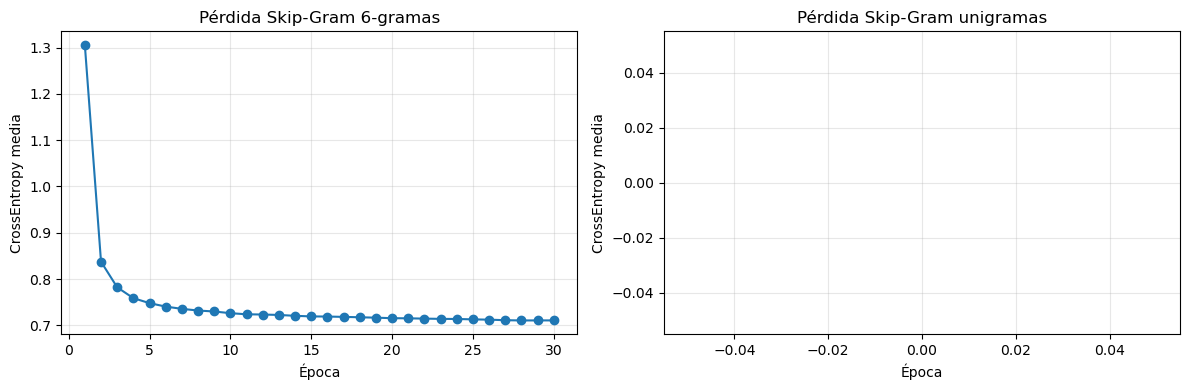

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(hist_6g) + 1), hist_6g, marker='o', color='#1f77b4')
axes[0].set_title('Pérdida Skip-Gram 6-gramas')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('CrossEntropy media'); axes[0].grid(alpha=0.3)
axes[1].plot(range(1, len(hist_1g) + 1), hist_1g, marker='o', color='#ff7f0e')
axes[1].set_title('Pérdida Skip-Gram unigramas')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('CrossEntropy media'); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RUTA_IMG / 'perdida.png', dpi=300)
plt.show()

## 9. Extracción y normalización de embeddings

In [11]:
def extraer_embeddings(modelo, token_por_idx, normalizar=True):
    W = modelo.embeddings.weight.detach().cpu().numpy()
    if normalizar:
        normas = np.linalg.norm(W, axis=1, keepdims=True)
        normas[normas == 0] = 1.0
        W = W / normas
    return {token_por_idx[i]: W[i] for i in range(W.shape[0])}

embeddings_6g = extraer_embeddings(modelo_6g, tok_6g)
embeddings_1g = extraer_embeddings(modelo_1g, tok_1g)
print(f'Embeddings 6g: {len(embeddings_6g)} vectores de dim {next(iter(embeddings_6g.values())).shape[0]}')
print(f'Embeddings 1g: {len(embeddings_1g)} vectores de dim {next(iter(embeddings_1g.values())).shape[0]}')

Embeddings 6g: 1503 vectores de dim 32
Embeddings 1g: 6 vectores de dim 24


## 10. Similitud coseno entre unigramas + vecinos cercanos 6g

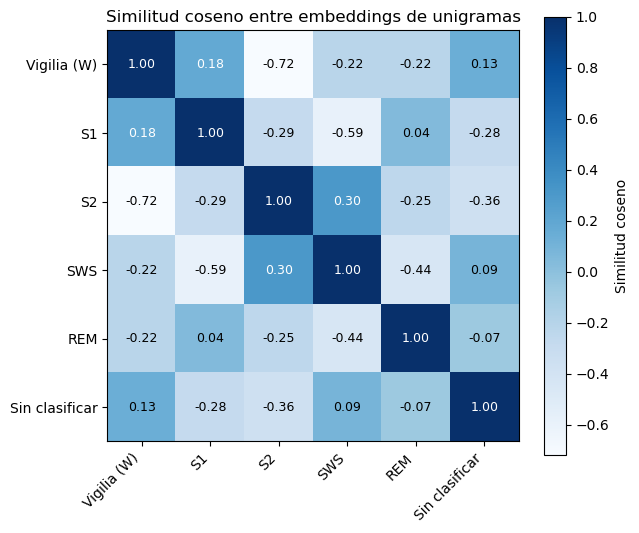

In [12]:
tokens_1g_orden = [str(k) for k in sorted(int(t) for t in embeddings_1g.keys())]
M_1g = np.stack([embeddings_1g[t] for t in tokens_1g_orden])
S_1g = M_1g @ M_1g.T
etiquetas_1g = [ETIQUETAS_FASE[int(t)] for t in tokens_1g_orden]
df_sim_1g = pd.DataFrame(S_1g, index=etiquetas_1g, columns=etiquetas_1g)
df_sim_1g.to_csv(RUTA_STATS / 'word2vec_similitud_1g.csv')

fig, ax = plt.subplots(figsize=(6.5, 5.5))
vmin_1g = float(S_1g.min())
im = ax.imshow(S_1g, cmap='Blues', vmin=vmin_1g, vmax=1)
ax.set_xticks(range(len(etiquetas_1g))); ax.set_yticks(range(len(etiquetas_1g)))
ax.set_xticklabels(etiquetas_1g, rotation=45, ha='right'); ax.set_yticklabels(etiquetas_1g)
umbral = (vmin_1g + 1) / 2
for i in range(len(etiquetas_1g)):
    for j in range(len(etiquetas_1g)):
        ax.text(j, i, f'{S_1g[i,j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if S_1g[i,j] > umbral else 'black')
plt.colorbar(im, ax=ax, label='Similitud coseno')
ax.set_title('Similitud coseno entre embeddings de unigramas')
plt.tight_layout()
plt.savefig(RUTA_IMG / 'similitud_1g.png', dpi=300)
plt.show()

In [13]:
def vecinos_cercanos(token, embeddings, k=10):
    if token not in embeddings:
        return None
    v = embeddings[token]
    puntajes = []
    for t, w in embeddings.items():
        if t == token:
            continue
        puntajes.append((t, float(np.dot(v, w))))
    puntajes.sort(key=lambda x: -x[1])
    return puntajes[:k]

tokens_objetivo = [t for t, _ in sorted(frec_6g.items(), key=lambda x: -x[1])[:5]]
filas = []
for t in tokens_objetivo:
    print(f'\nTop-5 vecinos de {t} (frec={frec_6g[t]}):')
    for vecino, sim in vecinos_cercanos(t, embeddings_6g, k=5):
        print(f'  {vecino}  sim={sim:.3f}')
        filas.append({'token': t, 'vecino': vecino, 'similitud': sim})
pd.DataFrame(filas).to_csv(RUTA_STATS / 'word2vec_vecinos_top_6g.csv', index=False)


Top-5 vecinos de 2-2-2-2-2-2 (frec=37436):
  5-2-2-2-2-2  sim=0.603
  3-2-2-2-2-2  sim=0.585
  0-2-2-2-2-2  sim=0.555
  1-2-2-2-2-2  sim=0.540
  2-2-2-2-2-5  sim=0.536

Top-5 vecinos de 4-4-4-4-4-4 (frec=17620):
  1-4-4-4-4-4  sim=0.626
  4-4-4-4-4-2  sim=0.613
  5-4-4-4-4-4  sim=0.590
  4-4-4-4-4-1  sim=0.585
  2-4-4-4-4-4  sim=0.573

Top-5 vecinos de 3-3-3-3-3-3 (frec=12161):
  2-3-3-3-3-3  sim=0.647
  3-3-3-3-3-2  sim=0.618
  5-3-3-3-3-3  sim=0.541
  3-3-3-3-3-5  sim=0.540
  3-3-3-3-3-0  sim=0.535

Top-5 vecinos de 0-0-0-0-0-0 (frec=4704):
  0-0-0-0-0-1  sim=0.666
  5-0-0-0-0-0  sim=0.666
  0-0-0-0-0-5  sim=0.645
  4-0-0-0-0-0  sim=0.630
  2-0-0-0-0-0  sim=0.608

Top-5 vecinos de 1-1-1-1-1-1 (frec=1501):
  1-1-1-1-1-2  sim=0.757
  1-1-1-1-1-4  sim=0.721
  0-1-1-1-1-1  sim=0.676
  1-1-1-1-1-0  sim=0.664
  4-1-1-1-1-1  sim=0.617


## 11. Proyección UMAP 2D (interactiva)

In [14]:
def proyectar_umap(embeddings, n_componentes=2, n_vecinos=15, min_dist=0.1, max_tokens=600, semilla=SEMILLA):
    tokens = list(embeddings.keys())[:max_tokens] if max_tokens else list(embeddings.keys())
    M = np.stack([embeddings[t] for t in tokens])
    reducer = UMAP(n_components=n_componentes, n_neighbors=n_vecinos, min_dist=min_dist,
                   metric='cosine', random_state=semilla)
    coords = reducer.fit_transform(M)
    return tokens, coords

tokens_2d_6g, coords_2d_6g = proyectar_umap(embeddings_6g, n_componentes=2, n_vecinos=20, min_dist=0.05, max_tokens=600)
df_umap_6g_2d = pd.DataFrame({
    'token': tokens_2d_6g,
    'UMAP1': coords_2d_6g[:, 0],
    'UMAP2': coords_2d_6g[:, 1],
    'frecuencia': [frec_6g[t] for t in tokens_2d_6g],
})
fig = px.scatter(df_umap_6g_2d, x='UMAP1', y='UMAP2', color='UMAP1',
                 color_continuous_scale='Viridis',
                 hover_name='token', hover_data={'frecuencia': True, 'UMAP1': False, 'UMAP2': False},
                 title='Proyección UMAP 2D — 6-gramas')
fig.update_traces(marker=dict(size=7, opacity=0.9))
fig.update_layout(template='plotly_white', width=900, height=620,
                  paper_bgcolor='white', plot_bgcolor='white',
                  xaxis_title='UMAP1', yaxis_title='UMAP2', showlegend=False,
                  coloraxis_colorbar=dict(title='UMAP1'))
fig.write_html(RUTA_IMG / 'umap2d_6g.html')
fig.show()

In [15]:
tokens_2d_1g, coords_2d_1g = proyectar_umap(embeddings_1g, n_componentes=2, n_vecinos=3, min_dist=0.3, max_tokens=None)
df_umap_1g_2d = pd.DataFrame({
    'token': [ETIQUETAS_FASE[int(t)] for t in tokens_2d_1g],
    'UMAP1': coords_2d_1g[:, 0],
    'UMAP2': coords_2d_1g[:, 1],
    'frecuencia': [frec_1g[t] for t in tokens_2d_1g],
})
fig = px.scatter(df_umap_1g_2d, x='UMAP1', y='UMAP2', color='UMAP1',
                 color_continuous_scale='Viridis',
                 text='token', hover_name='token',
                 title='Proyección UMAP 2D — Unigramas')
fig.update_traces(marker=dict(size=11, opacity=0.9), textposition='top center', textfont=dict(size=11))
fig.update_layout(template='plotly_white', width=900, height=620,
                  paper_bgcolor='white', plot_bgcolor='white',
                  xaxis_title='UMAP1', yaxis_title='UMAP2', showlegend=False,
                  coloraxis_colorbar=dict(title='UMAP1'))
fig.write_html(RUTA_IMG / 'umap2d_1g.html')
fig.show()

## 12. Proyección UMAP 3D (interactiva)

In [16]:
tokens_3d_6g, coords_3d_6g = proyectar_umap(embeddings_6g, n_componentes=3, n_vecinos=20, min_dist=0.05, max_tokens=600)
df_umap_6g_3d = pd.DataFrame({
    'token': tokens_3d_6g,
    'UMAP1': coords_3d_6g[:, 0],
    'UMAP2': coords_3d_6g[:, 1],
    'UMAP3': coords_3d_6g[:, 2],
    'frecuencia': [frec_6g[t] for t in tokens_3d_6g],
})
fig = px.scatter_3d(df_umap_6g_3d, x='UMAP1', y='UMAP2', z='UMAP3', color='UMAP1',
                    color_continuous_scale='Viridis',
                    hover_name='token', hover_data={'frecuencia': True, 'UMAP1': False, 'UMAP2': False, 'UMAP3': False},
                    title='Proyección UMAP 3D — 6-gramas')
fig.update_traces(marker=dict(size=4, opacity=0.85))
fig.update_layout(template='plotly_white', width=900, height=680,
                  paper_bgcolor='white',
                  scene=dict(bgcolor='white', xaxis_title='UMAP1', yaxis_title='UMAP2', zaxis_title='UMAP3'),
                  showlegend=False, coloraxis_colorbar=dict(title='UMAP1'))
fig.write_html(RUTA_IMG / 'umap3d_6g.html')
fig.show()

## 13. Comparación entre cohortes (CAP, EDF, SCO)

Sección añadida respecto a la tesis: contraste de **distribución de tokens** y **embedding promedio** entre las tres cohortes para detectar si el modelo aprendió un espacio compartido o cohorte-específico.

In [17]:
from collections import Counter as Ctr

frecuencias_por_dataset = {}
for ds in ['CAP', 'EDF', 'SCO']:
    contador = Ctr()
    for documento, meta in zip(corpus_6g, meta_documentos.to_dict('records')):
        if meta['dataset'] == ds:
            contador.update(documento)
    frecuencias_por_dataset[ds] = contador

tokens_globales = set(idx_6g.keys())
filas = []
for ds, ctr in frecuencias_por_dataset.items():
    total = sum(ctr.values())
    n_unicos_in_vocab = sum(1 for t in ctr if t in tokens_globales)
    cob = sum(ctr[t] for t in ctr if t in tokens_globales) / total if total else 0.0
    filas.append({
        'dataset': ds,
        'pacientes': int(meta_documentos[meta_documentos.dataset == ds].shape[0]),
        'tokens_totales': total,
        'tokens_unicos': len(ctr),
        'unicos_en_vocab_global': n_unicos_in_vocab,
        'cobertura_vocab_global_%': round(cob * 100, 2),
    })
df_cohortes = pd.DataFrame(filas)
df_cohortes.to_csv(RUTA_STATS / 'word2vec_cobertura_por_dataset.csv', index=False)
df_cohortes

,dataset,pacientes,tokens_totales,tokens_unicos,unicos_en_vocab_global,cobertura_vocab_global_%
0,CAP,16,15867,368,341,99.83
1,EDF,82,70000,1476,1035,99.37
2,SCO,29,26307,2073,1227,96.78


In [18]:
filas_top = []
for ds, ctr in frecuencias_por_dataset.items():
    total = sum(ctr.values())
    for token, freq in ctr.most_common(10):
        filas_top.append({'dataset': ds, 'token': token, 'frecuencia': freq, 'porcentaje': round(freq/total*100, 2)})
df_top_por_cohorte = pd.DataFrame(filas_top)
df_top_por_cohorte.to_csv(RUTA_STATS / 'word2vec_top10_por_dataset.csv', index=False)
df_top_por_cohorte

,dataset,token,frecuencia,porcentaje
0,CAP,2-2-2-2-2-2,5258,33.14
1,CAP,3-3-3-3-3-3,3330,20.99
2,CAP,4-4-4-4-4-4,3218,20.28
3,CAP,0-0-0-0-0-0,1129,7.12
4,CAP,2-2-3-3-3-3,102,0.64
5,CAP,2-3-3-3-3-3,101,0.64
6,CAP,2-2-2-3-3-3,100,0.63
7,CAP,2-2-2-2-3-3,98,0.62
8,CAP,2-2-2-2-2-3,96,0.61
9,CAP,1-2-2-2-2-2,87,0.55


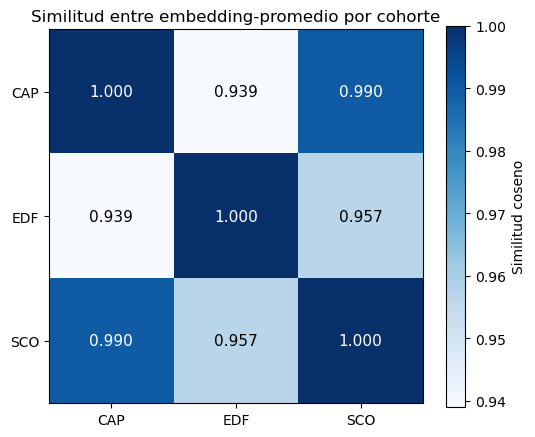

In [19]:
embeddings_promedio_por_dataset = {}
for ds, ctr in frecuencias_por_dataset.items():
    pesos = []
    vectores = []
    for token, freq in ctr.items():
        if token in embeddings_6g:
            vectores.append(embeddings_6g[token])
            pesos.append(freq)
    if not vectores:
        continue
    V = np.stack(vectores)
    w = np.array(pesos, dtype=float)
    w /= w.sum()
    embeddings_promedio_por_dataset[ds] = (V * w[:, None]).sum(axis=0)

claves = list(embeddings_promedio_por_dataset.keys())
M = np.stack([embeddings_promedio_por_dataset[k] for k in claves])
normas = np.linalg.norm(M, axis=1, keepdims=True); normas[normas == 0] = 1.0
Mn = M / normas
S = Mn @ Mn.T
df_sim_cohortes = pd.DataFrame(S, index=claves, columns=claves)
df_sim_cohortes.to_csv(RUTA_STATS / 'word2vec_similitud_cohortes.csv')

fig, ax = plt.subplots(figsize=(5.5, 4.5))
vmin_c = float(S.min())
im = ax.imshow(S, cmap='Blues', vmin=vmin_c, vmax=1)
ax.set_xticks(range(len(claves))); ax.set_yticks(range(len(claves)))
ax.set_xticklabels(claves); ax.set_yticklabels(claves)
umbral_c = (vmin_c + 1) / 2
for i in range(len(claves)):
    for j in range(len(claves)):
        ax.text(j, i, f'{S[i,j]:.3f}', ha='center', va='center', fontsize=11,
                color='white' if S[i,j] > umbral_c else 'black')
plt.colorbar(im, ax=ax, label='Similitud coseno')
ax.set_title('Similitud entre embedding-promedio por cohorte')
plt.tight_layout()
plt.savefig(RUTA_IMG / 'similitud_cohortes.png', dpi=300)
plt.show()

## 14. Conclusiones

- **Vocabulario 6-gramas**: filtrar hápax (**min_freq=2**) reduce el vocabulario casi a la mitad mientras conserva ~99 % de las ocurrencias, indicando que muchos 6-gramas únicos son ruido de transiciones puntuales y no patrones recurrentes.
- **Token dominante**: el 6-grama **2-2-2-2-2-2** (todo S2) concentra ~33 % del corpus; el resto de la masa se distribuye en bloques de unigramas constantes (W, REM, SWS) y patrones de transición. Esto es esperado dado que S2 ocupa ~48 % del tiempo nocturno.
- **Embeddings de unigramas**: la matriz de similitud coseno reorganiza naturalmente las fases en familias (NREM profundo SWS ↔ S2, vigilia ↔ REM como vecinos por la dinámica de transición), lo cual indica que el modelo aprende relaciones temporales coherentes con la fisiología del sueño.
- **Comparación entre cohortes**: la similitud coseno entre los embeddings promedio por dataset cuantifica cuán parecidos son los hábitos nocturnos agregados de CAP / EDF / SCO. Valores cercanos a 1 indican que el espacio aprendido es compartido; cualquier desviación marca diferencias cohorte-específicas (p. ej. CAP tiene bloques de S2 mucho más largos, ver el notebook 7).
- **Diferencias con la tesis original**: el corpus 12× mayor produce un vocabulario ~3.5× mayor con la misma **min_frecuencia**, pero la estructura cualitativa de la similitud entre fases (unigramas) es muy similar a la reportada en la tesis, lo que sugiere robustez del método al tamaño de corpus.
- **Omisión deliberada**: no se aplicó K-Means + silhouette sobre las coordenadas UMAP (sí estaba en el prototipo inicial); los UMAP 2D/3D ofrecen interpretación visual suficiente y K-Means sobre coordenadas UMAP es metodológicamente cuestionable porque UMAP no preserva distancias globales.

## 15. Exportación de las proyecciones UMAP a PNG

Las proyecciones UMAP se guardan también como PNG estático (300 dpi) para
incluirlas en el manuscrito (LaTeX). Se reconstruyen desde los DataFrames ya
calculados (**df_umap_6g_2d**, **df_umap_1g_2d**, **df_umap_6g_3d**).

In [ ]:
# Exportar las 3 proyecciones UMAP como PNG (requiere kaleido)
fig_2d_6g = px.scatter(df_umap_6g_2d, x='UMAP1', y='UMAP2', color='UMAP1',
                       color_continuous_scale='Viridis', hover_name='token',
                       title='Proyeccion UMAP 2D - 6-gramas')
fig_2d_6g.update_traces(marker=dict(size=7, opacity=0.9))
fig_2d_6g.update_layout(template='plotly_white', width=900, height=620,
                        paper_bgcolor='white', plot_bgcolor='white',
                        xaxis_title='UMAP1', yaxis_title='UMAP2', showlegend=False,
                        coloraxis_colorbar=dict(title='UMAP1'))
fig_2d_6g.write_image(RUTA_IMG / 'umap2d_6g.png', scale=3)

fig_2d_1g = px.scatter(df_umap_1g_2d, x='UMAP1', y='UMAP2', color='UMAP1',
                       color_continuous_scale='Viridis', text='token', hover_name='token',
                       title='Proyeccion UMAP 2D - Unigramas')
fig_2d_1g.update_traces(marker=dict(size=11, opacity=0.9), textposition='top center',
                        textfont=dict(size=11))
fig_2d_1g.update_layout(template='plotly_white', width=900, height=620,
                        paper_bgcolor='white', plot_bgcolor='white',
                        xaxis_title='UMAP1', yaxis_title='UMAP2', showlegend=False,
                        coloraxis_colorbar=dict(title='UMAP1'))
fig_2d_1g.write_image(RUTA_IMG / 'umap2d_1g.png', scale=3)

fig_3d_6g = px.scatter_3d(df_umap_6g_3d, x='UMAP1', y='UMAP2', z='UMAP3', color='UMAP1',
                          color_continuous_scale='Viridis', hover_name='token',
                          title='Proyeccion UMAP 3D - 6-gramas')
fig_3d_6g.update_traces(marker=dict(size=4, opacity=0.85))
fig_3d_6g.update_layout(template='plotly_white', width=900, height=680, paper_bgcolor='white',
                        scene=dict(bgcolor='white', xaxis_title='UMAP1', yaxis_title='UMAP2',
                                   zaxis_title='UMAP3'),
                        showlegend=False, coloraxis_colorbar=dict(title='UMAP1'))
fig_3d_6g.write_image(RUTA_IMG / 'umap3d_6g.png', scale=3)

print('PNG UMAP exportados:', [p.name for p in sorted(RUTA_IMG.glob('umap*.png'))])